#Khyati Sharma, Jigyasa Soni & Vishaka Sharma

**Aqua-Net: A Deep Dive into Aquatic Life**

#Importing Required Modules</center>

In [ ]:
import pandas as pd
import numpy as np
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
sns.set_style('darkgrid')
import shutil
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import  ReduceLROnPlateau,EarlyStopping,ModelCheckpoint
import time
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score
import sys
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Final_Project_Deep_Learning")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning/three_class_data.zip"

In [ ]:
import os

def count_images_in_classes(data_dir):

    """
    Count the number of images in each class for test, train, and val folders.

    :param data_dir: Path to the main dataset directory containing 'train', 'test', 'val' folders.
    :return: Dictionary with counts for each folder and class.
    """
    results = {}

    # Iterate through 'train', 'test', 'val' directories
    for folder in ['train', 'test', 'val']:
        folder_path = os.path.join(data_dir, folder)

        if not os.path.exists(folder_path):
            print(f"Folder '{folder}' does not exist in '{data_dir}'. Skipping...")
            continue

        class_counts = {}
        for class_name in os.listdir(folder_path):
            class_path = os.path.join(folder_path, class_name)

            if os.path.isdir(class_path):
                # Count image files in the class folder
                num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
                class_counts[class_name] = num_images

        results[folder] = class_counts

    return results

def print_results(results):
    """
    Print the results in a readable format.

    :param results: Dictionary with counts for each folder and class.
    """
    for folder, class_counts in results.items():
        print(f"\n{folder.upper()} SET:")
        for class_name, count in class_counts.items():
            print(f"  {class_name}: {count} images")

# Main directory containing 'train', 'test', 'val'
data_directory = "/content/drive/MyDrive/Final_Project_Deep_Learning/split_data"

# Count images in each class
results = count_images_in_classes(data_directory)

# Print the results
print_results(results)



TRAIN SET:
  Turtle_Tortoise: 1332 images
  Dolphin: 547 images
  Jelly Fish: 591 images

TEST SET:
  Turtle_Tortoise: 286 images
  Dolphin: 118 images
  Jelly Fish: 127 images

VAL SET:
  Turtle_Tortoise: 285 images
  Dolphin: 117 images
  Jelly Fish: 127 images


Class 'Turtle_Tortoise': 1332 images
Class 'Dolphin': 547 images
Class 'Jelly Fish': 591 images


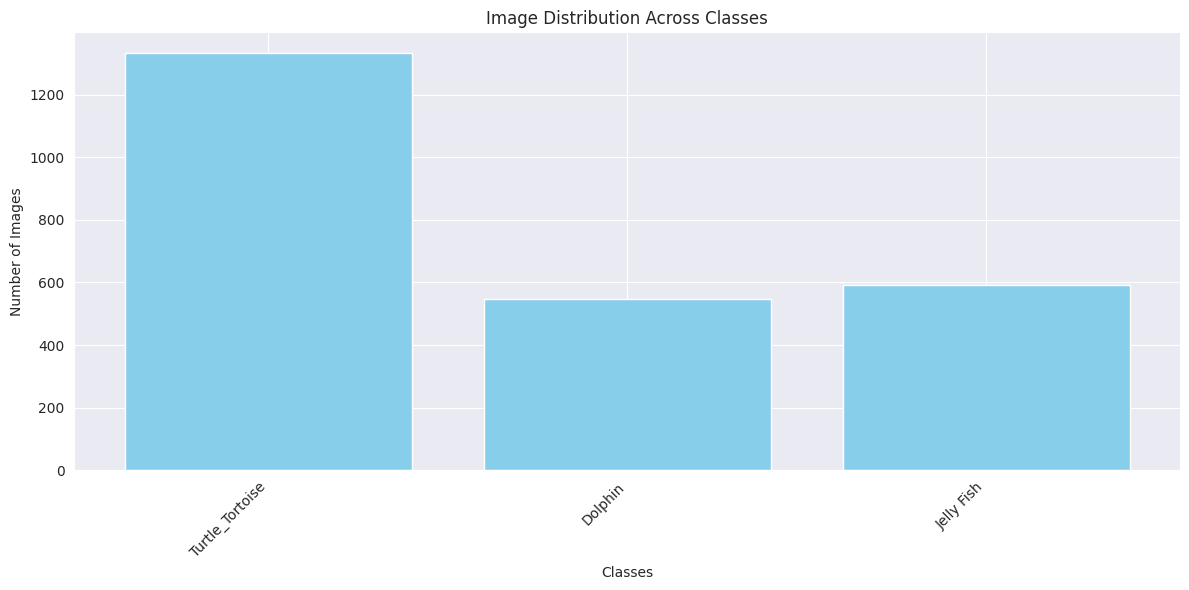

In [ ]:
# plot training data distribution
import os
import matplotlib.pyplot as plt
def count_images_per_class(dataset_path):
    class_image_counts = {}
    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            class_image_counts[class_name] = len(image_files)

    return class_image_counts

def plot_image_distribution(image_counts):
    classes = list(image_counts.keys())
    counts = list(image_counts.values())

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.title('Image Distribution Across Classes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

dataset_path = "/content/drive/MyDrive/Final_Project_Deep_Learning/split_data/train"
image_counts = count_images_per_class(dataset_path)
for class_name, count in image_counts.items():
    print(f"Class '{class_name}': {count} images")
plot_image_distribution(image_counts)


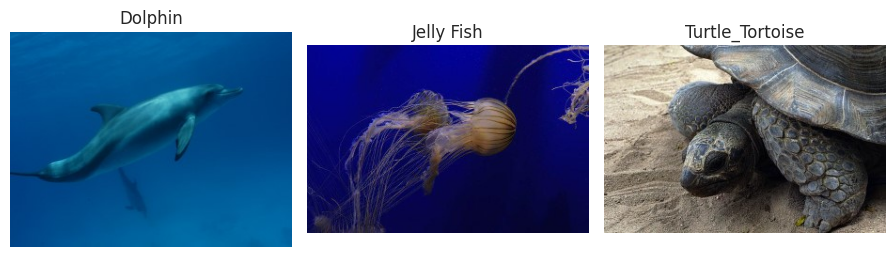

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Define the path to the train folder
train_folder = '/content/drive/MyDrive/Final_Project_Deep_Learning/split_data/train'

# Get the class names (subfolder names)
class_names = sorted(os.listdir(train_folder))

# Initialize a figure to display images
plt.figure(figsize=(15, 10))

# Loop through each class and display one image
for i, class_name in enumerate(class_names):
    # Get the path to the class folder
    class_folder = os.path.join(train_folder, class_name)

    # Get a list of all image files in the class folder
    image_files = [f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))]

    if image_files:  # Check if there are images in the folder
        # Get the path to the first image
        image_path = os.path.join(class_folder, image_files[0])

        # Load the image
        img = load_img(image_path)

        # Add the image to the plot
        plt.subplot(len(class_names) // 5 + 1, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(class_name)

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

def create_generators(main_dir, img_size, batch_size):

    # Paths to subdirectories
    train_dir = os.path.join(main_dir, 'train')
    val_dir = os.path.join(main_dir, 'val')
    test_dir = os.path.join(main_dir, 'test')

    # ImageDataGenerator for rescaling
    datagen = ImageDataGenerator(rescale=1.0 / 255)

    # Train generator
    print("Creating train generator...")
    train_gen = datagen.flow_from_directory(
        directory=train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',  # Use 'binary' for binary classification
        shuffle=True,
        color_mode='rgb'
    )

    # Validation generator
    print("Creating validation generator...")
    valid_gen = datagen.flow_from_directory(
        directory=val_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,
        color_mode='rgb'
    )

    # Test generator
    print("Creating test generator...")
    test_gen = datagen.flow_from_directory(
        directory=test_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,
        color_mode='rgb'
    )

    # Retrieve class labels
    classes = list(train_gen.class_indices.keys())
    print(f"Classes found: {classes}")

    return train_gen, valid_gen, test_gen, classes


# Example usage
main_dir = "/content/drive/MyDrive/Final_Project_Deep_Learning/split_data"  # Main folder containing 'train', 'val', 'test'
img_size = (224, 224)            # Image size for resizing
batch_size = 32                  # Batch size for generators

train_gen, valid_gen, test_gen, classes = create_generators(main_dir, img_size, batch_size)

# Example: Display generator details
print(f"Number of classes: {len(classes)}")
print(f"Class labels: {classes}")


Creating train generator...
Found 2470 images belonging to 3 classes.
Creating validation generator...
Found 529 images belonging to 3 classes.
Creating test generator...
Found 531 images belonging to 3 classes.
Classes found: ['Dolphin', 'Jelly Fish', 'Turtle_Tortoise']
Number of classes: 3
Class labels: ['Dolphin', 'Jelly Fish', 'Turtle_Tortoise']


In [ ]:
from keras.layers import Dropout, Dense, Flatten, BatchNormalization, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from keras import layers
from keras.models import Sequential
from keras.callbacks import EarlyStopping

early_stop=EarlyStopping(monitor='val_loss',patience=3)
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(224, 224, 3)))
  model.add(BatchNormalization())

  # model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  #model.add(Dropout(0.2))

  model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  # model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  # model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  # model.add(Dropout(0.3))
  model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  # model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  # model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  # model.add(Dropout(0.4))
  model.add(Flatten())
  model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))
  model.add(Dense(3, activation='softmax'))

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath='best_model.keras',  # Save the model in .h5 format
        monitor='val_loss',
        save_best_only=True,  # Save only the best model
        mode='min',  # Minimizing the validation loss
        verbose=1  # Print updates during training
    ),
    EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=5,  # Stop training after 5 epochs of no improvement
        verbose=1,  # Print when stopping
        mode='min'  # Minimizing the validation loss
    )
]
print(model.summary())

epochs = 40
history=model.fit(x=train_gen,  epochs=epochs, verbose=1, validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,940,355 (49.36 MB)

 Trainable params: 12,939,587 (49.36 MB)

 Non-trainable params: 768 (3.00 KB)

None


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 238ms/step - accuracy: 0.7723 - loss: 0.7952 - val_accuracy: 0.6352 - val_loss: 0.7377
Epoch 2/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 265ms/step - accuracy: 0.8357 - loss: 0.4678 - val_accuracy: 0.7505 - val_loss: 0.6710
Epoch 3/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 221ms/step - accuracy: 0.8760 - loss: 0.3699 - val_accuracy: 0.8242 - val_loss: 0.4695
Epoch 4/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.8849 - loss: 0.3377 - val_accuracy: 0.8582 - val_loss: 0.3603
Epoch 5/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - accuracy: 0.8999 - loss: 0.3002 - val_accuracy: 0.8374 - val_loss: 0.4734
Epoch 6/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 221ms/step - accuracy: 0.9056 - loss: 0.2606 - val_accuracy: 0.8771 - val_loss: 0.3408
Epoch 7/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 236ms/step - accuracy: 0.9060 - loss: 0.2466 - val_accuracy: 0.8885 - val_loss: 0.2956
Epoch 8/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.9411 - loss: 0.1855 - val_accu

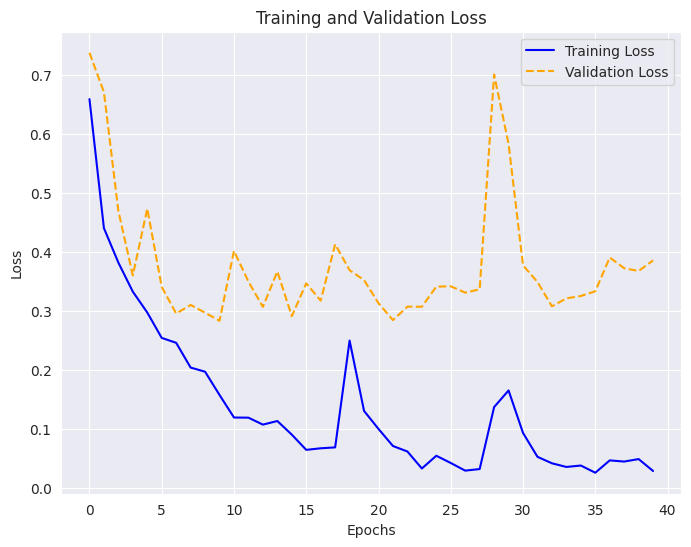

In [ ]:
import matplotlib.pyplot as plt

# Assuming `history` is the output from model.fit
def plot_training_history(history):
    # Get training and validation loss
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Create a plot
    plt.figure(figsize=(8, 6))
    plt.plot(train_loss, label='Training Loss', color='blue', linestyle='-')
    plt.plot(val_loss, label='Validation Loss', color='orange', linestyle='--')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the function to plot
plot_training_history(history)


In [ ]:
def evaluate(test_gen):
    y_pred= []
    error_list=[]
    error_pred_list = []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        file=test_gen.filenames[i]
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
            error_class=classes[pred_index]
            t=(file, error_class)
            error_list.append(t)
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    msg=f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}'
    print(msg) # cyan foreground
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    f1score=f1_score(ytrue, ypred, average='weighted')* 100
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests, error_list, f1score

#Evaluating The Model

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step
there were 60 errors in 531 tests for an accuracy of  88.70


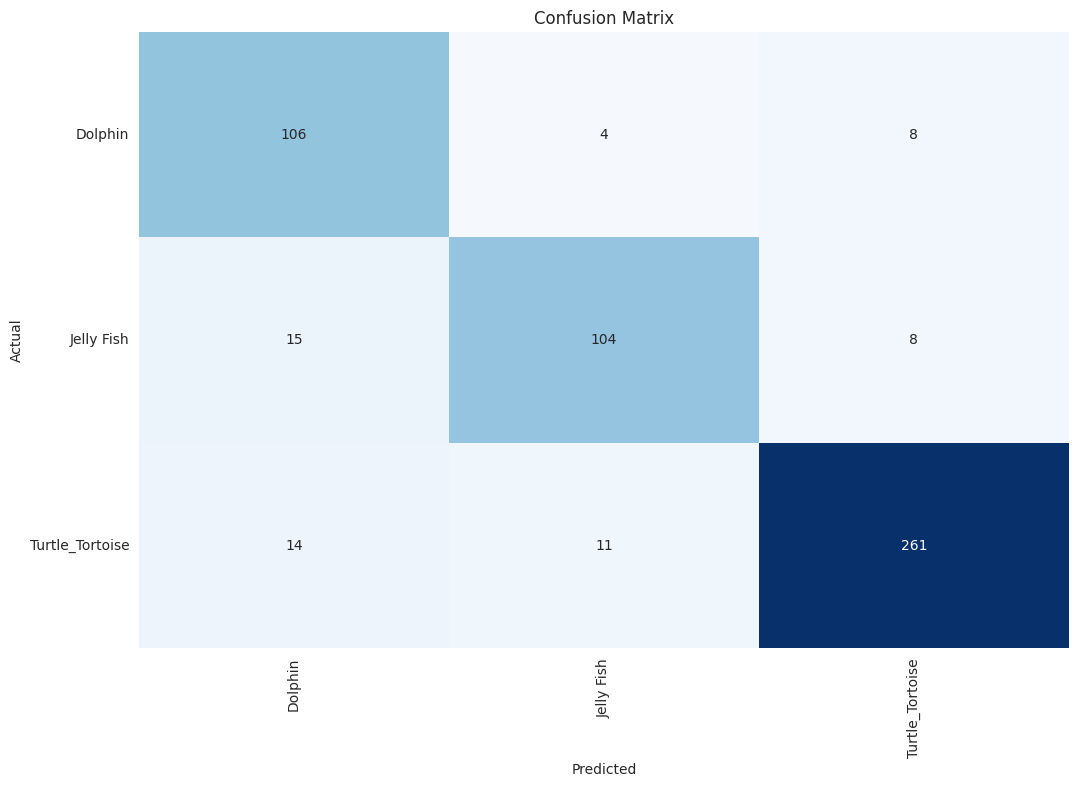

Classification Report:
----------------------
                  precision    recall  f1-score   support

        Dolphin     0.7852    0.8983    0.8379       118
     Jelly Fish     0.8739    0.8189    0.8455       127
Turtle_Tortoise     0.9422    0.9126    0.9272       286

       accuracy                         0.8870       531
      macro avg     0.8671    0.8766    0.8702       531
   weighted avg     0.8910    0.8870    0.8878       531



In [ ]:
errors, tests, error_list, f1score =evaluate(test_gen)

In [ ]:
#saving the trainned model
working_dir=r'/content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning/'
subject='sea animals'
save_id=f'{subject}-{f1score:5.2f}.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
msg= f'model was saved as {model_save_loc}'
print(msg)

model was saved as /content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning/sea animals-88.78.h5


#Generating Augmented Data and Training the Model Using Data Augmentation

Data augmentation so that each class contains equal number of images.  
Technique use are :

* Horiontal flip = True
* rotation_range = 20
* width_shift_range =
* height_shift_range=0.2
* zoom_range = 0.2

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

def create_generators(main_dir, img_size, batch_size):
    """
    Create ImageDataGenerator instances for train, validation, and test datasets with augmentations for the train data.

    Args:
        main_dir (str): Path to the main directory containing 'train', 'val', and 'test' subdirectories.
        img_size (tuple): Target size for resizing images, e.g., (224, 224).
        batch_size (int): Batch size for the generators.

    Returns:
        tuple: train_gen, valid_gen, test_gen, classes
    """
    # Paths to subdirectories
    train_dir = os.path.join(main_dir, 'train')
    val_dir = os.path.join(main_dir, 'val')
    test_dir = os.path.join(main_dir, 'test')

    # ImageDataGenerator for training with augmentations
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,  # Rescaling
        horizontal_flip=True,  # Horizontal flip
        rotation_range=20,  # Random rotation
        width_shift_range=0.2,  # Random width shift
        height_shift_range=0.2,  # Random height shift
        zoom_range=0.2  # Random zoom
    )

    # ImageDataGenerator for validation and test data (only rescaling)
    datagen = ImageDataGenerator(rescale=1.0 / 255)

    # Train generator with augmentations
    print("Creating train generator...")
    train_gen = train_datagen.flow_from_directory(
        directory=train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',  # Use 'binary' for binary classification
        shuffle=True,
        color_mode='rgb'
    )

    # Validation generator (no augmentation, only rescaling)
    print("Creating validation generator...")
    valid_gen = datagen.flow_from_directory(
        directory=val_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,  # No shuffling in validation data
        color_mode='rgb'
    )

    # Test generator (no augmentation, only rescaling)
    print("Creating test generator...")
    test_gen = datagen.flow_from_directory(
        directory=test_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,  # No shuffling in test data
        color_mode='rgb'
    )

    # Retrieve class labels
    classes = list(train_gen.class_indices.keys())
    print(f"Classes found: {classes}")

    return train_gen, valid_gen, test_gen, classes


# Example usage
main_dir = "/content/drive/MyDrive/Final_Project_Deep_Learning/split_data"  # Main folder containing 'train', 'val', 'test'
img_size = (224, 224)            # Image size for resizing
batch_size = 32                # Batch size for generators

train_gen, valid_gen, test_gen, classes = create_generators(main_dir, img_size, batch_size)

# Example: Display generator details
print(f"Number of classes: {len(classes)}")
print(f"Class labels: {classes}")


Creating train generator...
Found 2470 images belonging to 3 classes.
Creating validation generator...
Found 529 images belonging to 3 classes.
Creating test generator...
Found 531 images belonging to 3 classes.
Classes found: ['Dolphin', 'Jelly Fish', 'Turtle_Tortoise']
Number of classes: 3
Class labels: ['Dolphin', 'Jelly Fish', 'Turtle_Tortoise']


NOTE : this cell might take litle more time to **run**

#Plotting Augmented Images

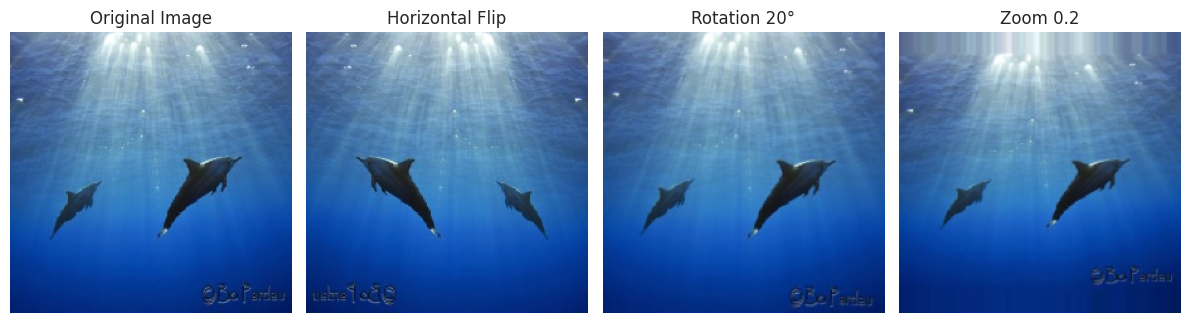

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

def visualize_four_augmentations(image_path, img_size):
    augmentations = [
        {"name": "Original Image", "gen": ImageDataGenerator()},
        {"name": "Horizontal Flip", "gen": ImageDataGenerator(horizontal_flip=True)},
        {"name": "Rotation 20°", "gen": ImageDataGenerator(rotation_range=20)},
        {"name": "Zoom 0.2", "gen": ImageDataGenerator(zoom_range=0.2)},
    ]

    # Load and preprocess the image
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Plot the original image and augmentations
    plt.figure(figsize=(12, 6))
    for i, aug in enumerate(augmentations):
        aug_gen = aug["gen"].flow(img_array, batch_size=1)  # Generate augmented image
        augmented_img = next(aug_gen)[0].astype('uint8')  # Get augmented image

        plt.subplot(1, 4, i + 1)
        plt.imshow(augmented_img)
        plt.axis('off')
        plt.title(aug["name"])  # Set title to the name of the augmentation

    plt.tight_layout()
    plt.show()


image_path = '/content/drive/MyDrive/Final_Project_Deep_Learning/split_data/val/Dolphin/11331713213_37a9acd23c_b.jpg'  # Path to a sample image
img_size = (224, 224)  # Target image size
visualize_four_augmentations(image_path, img_size)


In [ ]:

early_stop=EarlyStopping(monitor='val_loss',patience=3)
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(224, 224, 3)))
  model.add(BatchNormalization())

  # model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  #model.add(Dropout(0.2))

  model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  # model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  # model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  # model.add(Dropout(0.3))
  model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  model.add(BatchNormalization())
  # model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
  # model.add(BatchNormalization())
  model.add(MaxPooling2D((2, 2)))
  # model.add(Dropout(0.4))
  model.add(Flatten())
  model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))
  model.add(Dense(3, activation='softmax'))

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


callbacks = [
    ModelCheckpoint(
        filepath='best_model.keras',  # Save the model in .h5 format
        monitor='val_loss',
        save_best_only=True,  # Save only the best model
        mode='min',  # Minimizing the validation loss
        verbose=1  # Print updates during training
    ),
    EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=5,  # Stop training after 5 epochs of no improvement
        verbose=1,  # Print when stopping
        mode='min'  # Minimizing the validation loss
    )
]

print(model.summary())

epochs = 40
history=model.fit(x=train_gen,  epochs=epochs, verbose=1, validation_data=valid_gen,
               validation_steps=None,  shuffle=True,  initial_epoch=0)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,940,355 (49.36 MB)

 Trainable params: 12,939,587 (49.36 MB)

 Non-trainable params: 768 (3.00 KB)

None


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 62s 725ms/step - accuracy: 0.7661 - loss: 0.9205 - val_accuracy: 0.6106 - val_loss: 0.8276
Epoch 2/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 53s 617ms/step - accuracy: 0.8088 - loss: 0.5904 - val_accuracy: 0.7958 - val_loss: 0.5580
Epoch 3/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 60s 677ms/step - accuracy: 0.8334 - loss: 0.4571 - val_accuracy: 0.7089 - val_loss: 0.7974
Epoch 4/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 54s 637ms/step - accuracy: 0.8483 - loss: 0.4544 - val_accuracy: 0.8034 - val_loss: 0.5304
Epoch 5/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 60s 732ms/step - accuracy: 0.8470 - loss: 0.4269 - val_accuracy: 0.8110 - val_loss: 0.4507
Epoch 6/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 65s 783ms/step - accuracy: 0.8473 - loss: 0.4389 - val_accuracy: 0.8828 - val_loss: 0.3363
Epoch 7/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 82s 760ms/step - accuracy: 0.8699 - loss: 0.3689 - val_accuracy: 0.8639 - val_loss: 0.3781
Epoch 8/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 57s 666ms/step - accuracy: 0.8753 - loss: 0.3590 - val_accu

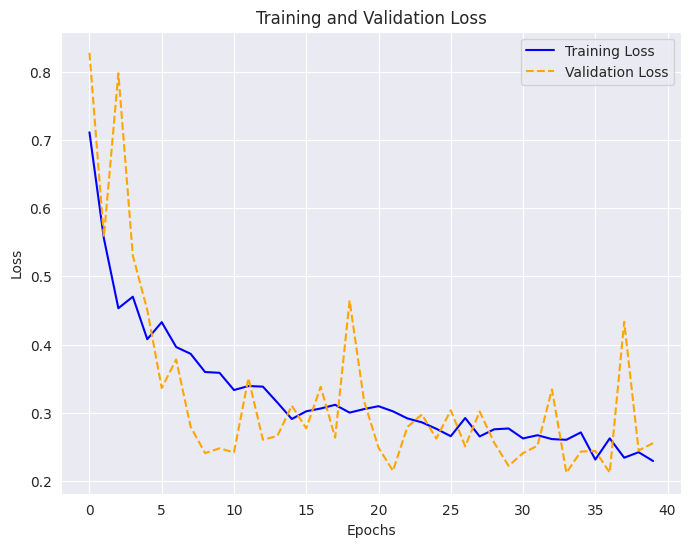

In [ ]:
# Call the function to plot
plot_training_history(history)


# Evaluating The Model

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step
there were 53 errors in 531 tests for an accuracy of  90.02


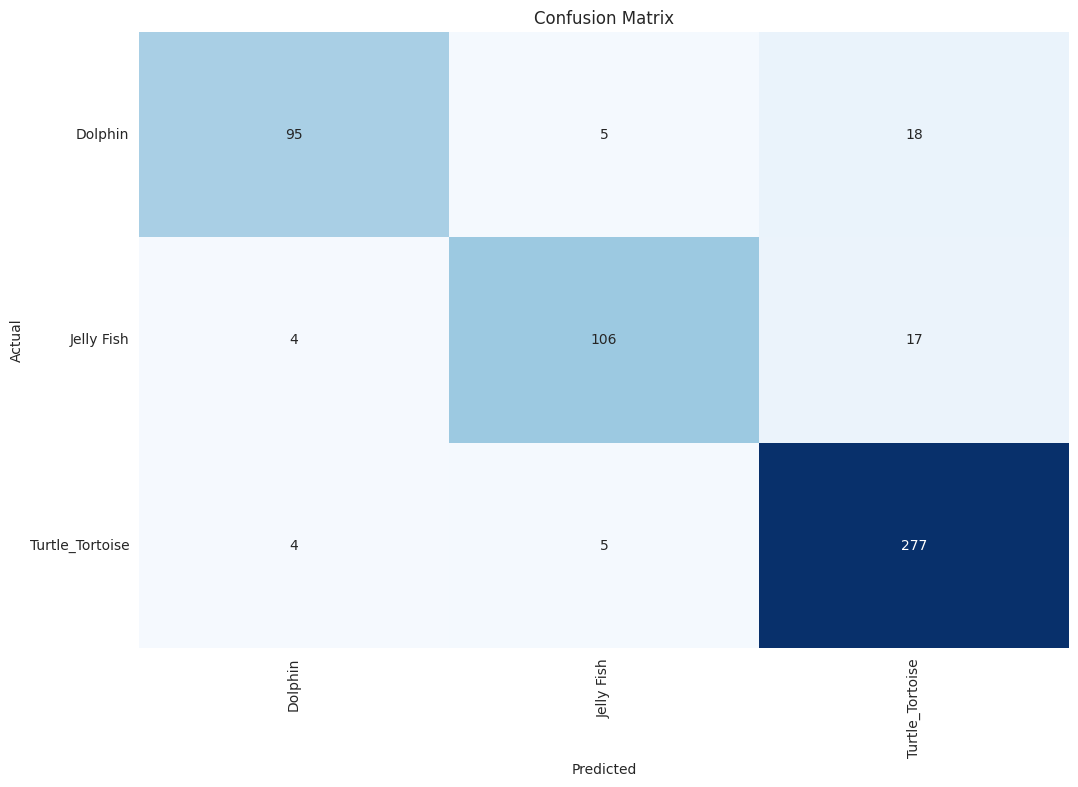

Classification Report:
----------------------
                  precision    recall  f1-score   support

        Dolphin     0.9223    0.8051    0.8597       118
     Jelly Fish     0.9138    0.8346    0.8724       127
Turtle_Tortoise     0.8878    0.9685    0.9264       286

       accuracy                         0.9002       531
      macro avg     0.9080    0.8694    0.8862       531
   weighted avg     0.9017    0.9002    0.8987       531



In [ ]:
errors, tests, error_list, f1score =evaluate(test_gen)

In [ ]:
working_dir=r'/content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning'
subject='sea animals-efficient-'
save_id=f'{subject}-{f1score:5.2f}.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
msg= f'model was saved as {model_save_loc}'
print(msg)

model was saved as /content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning/sea animals-efficient--89.87.h5


<a id="show"></a>
# <center>Transfer Learning </center>
* Training on Custom Data Using EfficientNetB7

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

def make_model(img_size):
    img_shape = (img_size[0], img_size[1], 3)

    # EfficientNetB7 without 'pooling' argument
    base_model = tf.keras.applications.EfficientNetB7(
        include_top=False,
        weights="imagenet",
        input_shape=img_shape
    )

    msg = 'Created EfficientNet B7 model'

    base_model.trainable = True
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Use GlobalAveragePooling to reduce dimensionality
    x = BatchNormalization()(x)  # Batch normalization for stability
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)  # Dense layer with L2 regularization
    x = Dropout(0.5)(x)  # Dropout to prevent overfitting
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)  # Another Dense layer
    x = Dropout(0.4)(x)  # Dropout again to further regularize the network

    # Final output
    output = Dense(3, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

def make_model(img_size):
    # Image input shape
    img_shape = (img_size[0], img_size[1], 3)

    # Load the ResNet50 base model without the top layer
    base_model = tf.keras.applications.ResNet50(
        include_top=False,  # Exclude the final classification layers
        weights="imagenet",  # Use pre-trained ImageNet weights
        input_shape=img_shape
    )
    print('Created ResNet50 model')

    # Freeze the base model layers (optional: unfreeze some layers later if you want to fine-tune)
    base_model.trainable = True  # Set False to keep the ResNet50 layers frozen

    # Add custom layers on top of the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Use GlobalAveragePooling to reduce dimensionality
    x = BatchNormalization()(x)  # Batch normalization for stability
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)  # Dense layer with L2 regularization
    x = Dropout(0.5)(x)  # Dropout to prevent overfitting
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)  # Another Dense layer
    x = Dropout(0.4)(x)  # Dropout again to further regularize the network

    # Final output layer for 3 classes
    output = Dense(3, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=base_model.input, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:

# Define the decorator function
def train_decorator(train_function):
    def wrapper(model, train_data, val_data, epochs, batch_size, callbacks=None, *args, **kwargs):
        # Start timing the training process
        start_time = time.time()

        print("Starting training...")

        # Apply default callbacks if none are provided
        if callbacks is None:
            callbacks = [
                ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss", mode="min", verbose=1),
                EarlyStopping(monitor="val_loss", patience=5, mode="min", verbose=1)
            ]

        # Call the training function with the provided arguments
        history = train_function(model, train_data, val_data, epochs, batch_size, callbacks, *args, **kwargs)

        # Calculate and print the time taken for training
        end_time = time.time()
        print(f"Training completed in {end_time - start_time:.2f} seconds")

        # Return training history
        return history

    return wrapper

# The actual training function, which will be decorated
@train_decorator
def train_model(model, train_data, val_data, epochs, batch_size, callbacks):
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        shuffle = True
    )
    return history


<a id="callbacks"></a>
# <center>Instantiating a Custom Callback for Training the EfficientNetB7 Model


In [ ]:
# EarlyStopping: Stop when the validation loss has not improved for 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    mode='min',
    restore_best_weights=True  # Restore best weights when early stopping occurs
)

# ModelCheckpoint: Save the best model based on validation loss
model_checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

callbacks = [early_stopping, model_checkpoint]

epochs = 40       # Number of epochs for training
batch_size = 32   # Batch size for training

# Create model
model = make_model(img_size=(224, 224))
print(model.summary())
# Train the model using the decorated training function
history = train_model(model, train_gen, valid_gen, epochs, batch_size,callbacks)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 224, 224, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 64)   │          1,728 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 64)   │            256 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 64)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 64)   │            576 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 64)   │            256 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 64)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 64)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 64)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 16)       │          1,040 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 65,551,258 (250.06 MB)

 Trainable params: 65,235,411 (248.85 MB)

 Non-trainable params: 315,847 (1.20 MB)

None
Starting training...
Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8119 - loss: 11.4425 
Epoch 1: val_loss improved from inf to 10.96838, saving model to best_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 1678s 17s/step - accuracy: 0.8127 - loss: 11.4239 - val_accuracy: 0.2401 - val_loss: 10.9684
Epoch 2/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.9504 - loss: 5.8820
Epoch 2: val_loss improved from 10.96838 to 4.64564, saving model to best_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9504 - loss: 5.8700 - val_accuracy: 0.2401 - val_loss: 4.6456
Epoch 3/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.9606 - loss: 2.7134
Epoch 3: val_loss improved from 4.64564 to 3.12454, saving model to best_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9606 - loss: 2.7078 - val_accuracy: 0.4140 - val_loss: 3.1245
Epoch 4/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.9731 - loss: 1.2690
Epoch 4: val_loss improved from 3.12454 to 1.95320, saving model

# Evaluating The Model

17/17 ━━━━━━━━━━━━━━━━━━━━ 266s 15s/step
there were 27 errors in 531 tests for an accuracy of  94.92


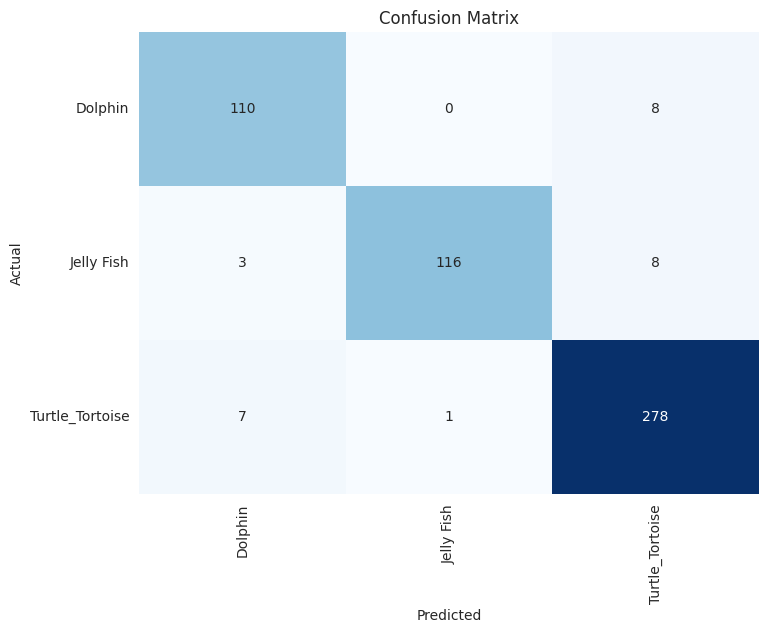

Classification Report:
----------------------
                  precision    recall  f1-score   support

        Dolphin     0.9167    0.9322    0.9244       118
     Jelly Fish     0.9915    0.9134    0.9508       127
Turtle_Tortoise     0.9456    0.9720    0.9586       286

       accuracy                         0.9492       531
      macro avg     0.9512    0.9392    0.9446       531
   weighted avg     0.9501    0.9492    0.9491       531



In [ ]:
errors, tests, error_list, f1score =evaluate(test_gen)

In [ ]:
print("Validation Loss over epochs:")
for epoch in range(len(history.history['val_loss'])):
    print(f"Epoch {epoch+1}: Validation Loss = {history.history['val_loss'][epoch]}")

Validation Loss over epochs:
Epoch 1: Validation Loss = 10.968378067016602
Epoch 2: Validation Loss = 4.64564323425293
Epoch 3: Validation Loss = 3.124537467956543
Epoch 4: Validation Loss = 1.9531962871551514
Epoch 5: Validation Loss = 62145.94921875
Epoch 6: Validation Loss = 4.026369094848633
Epoch 7: Validation Loss = 2.0255162715911865
Epoch 8: Validation Loss = 4.061318397521973
Epoch 9: Validation Loss = 0.7472755312919617
Epoch 10: Validation Loss = 0.49998149275779724
Epoch 11: Validation Loss = 0.35554733872413635
Epoch 12: Validation Loss = 0.2788771390914917
Epoch 13: Validation Loss = 0.2408534288406372
Epoch 14: Validation Loss = 0.24157917499542236
Epoch 15: Validation Loss = 0.18356581032276154
Epoch 16: Validation Loss = 0.24434694647789001
Epoch 17: Validation Loss = 0.6041899919509888
Epoch 18: Validation Loss = 2.6696724891662598
Epoch 19: Validation Loss = 0.9010420441627502
Epoch 20: Validation Loss = 0.5333196520805359


<a id="save"></a>
# <center>Save The Model

In [ ]:
working_dir=r'/content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning'
subject='sea animals-efficient-'
save_id=f'{subject}-{f1score:5.2f}.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
msg= f'model was saved as {model_save_loc}'
print(msg)

model was saved as /content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning/sea animals-efficient--94.91.h5
